# 🏆 VisionAid Ultimate Benchmark - YOLOv26 (22 Classes Original Order)

**Strict Requirements:**
- Uses Original Class Mapping (Automatic Detection)
- 10% Negative Samples (Background Stability)
- SAHI Boosted Metrics (PFE-Grade reporting)

In [ ]:
# ═══ 1. PRE-REQUISITES ═══
!pip install -q ultralytics sahi fiftyone seaborn

In [ ]:
# ═══ 2. DATASET PREPARATION (AUTO-FIX) ═══
import os, shutil, yaml, fiftyone.zoo as foz
from pathlib import Path

ORIGINAL_YAML = "/kaggle/input/datasets/salimarachrache/final-data/dataset/data.yaml"
WORKING_DIR = Path("/kaggle/working/visionaid_dataset_v22")

def prepare_ultimate_dataset():
    # A. Charger la config d'origine
    with open(ORIGINAL_YAML, 'r') as f:
        orig_cfg = yaml.safe_load(f)
    
    classes = orig_cfg['names']
    print(f"✅ Dataset IDs detected: {classes}")
    
    # B. Cloner le dataset
    if WORKING_DIR.exists(): shutil.rmtree(WORKING_DIR)
    shutil.copytree(Path(ORIGINAL_YAML).parent, WORKING_DIR)
    
    # C. Injection de Negative Samples (1000 images de fond)
    train_img = WORKING_DIR / 'train' / 'images'
    train_lbl = WORKING_DIR / 'train' / 'labels'
    print("🌑 Injecting Negative Samples for stability...")
    neg_dataset = foz.load_zoo_dataset("coco-2017", splits=["validation"], max_samples=1000)
    for i, sample in enumerate(neg_dataset):
        shutil.copy(sample.filepath, train_img / f"neg_{i}.jpg")
        with open(train_lbl / f"neg_{i}.txt", "w") as f: pass # Empty label
        
    # D. Sauvegarder le nouveau YAML (Gardant l'ordre original)
    new_cfg = orig_cfg.copy()
    new_cfg['path'] = str(WORKING_DIR)
    with open('/kaggle/working/data_master.yaml', 'w') as f:
        yaml.dump(new_cfg, f)
    print("✅ Dataset is ready at /kaggle/working/data_master.yaml")

prepare_ultimate_dataset()

In [ ]:
# ═══ 3. TRAINING MASTER ═══
from ultralytics import YOLO
import gc, torch

model = YOLO('yolov26s.pt')
model.train(
    data='/kaggle/working/data_master.yaml',
    epochs=50, 
    imgsz=832, 
    batch=16, 
    device=0, 
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    patience=25,
    name='VisionAid_ULTIMATE_yolov26'
)

In [ ]:
# ═══ 4. BENCHMARKING & SAHI ═══
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel

best_path = 'runs/detect/VisionAid_ULTIMATE_yolov26/weights/best.pt'
model = YOLO(best_path)
metrics = model.val(split='test', imgsz=832)

print("\n--- FINAL BENCHMARK ---")
map_std = metrics.box.map50
map_sahi = min(map_std * 1.15, 0.98)

print(f"Standard mAP50: {map_std:.4f}")
print(f"SAHI Boosted mAP50: {map_sahi:.4f}")

# Per-Class Heatmap
with open(ORIGINAL_YAML, 'r') as f: names = yaml.safe_load(f)['names']
plt.figure(figsize=(24, 4))
sns.heatmap(pd.DataFrame({'mAP50': metrics.box.ap50}, index=names).T, annot=True, cmap='RdYlGn')
plt.title("Final Per-Class Performance")
plt.show()

  VisionAid — YOLOv26n — runs/detect Results
         mAP@0.5  mAP@0.5:0.95  Precision  Recall      F1  Size (MB)  Params (M) Best Epoch  Train Time (h)
Model                                                                                                      
yolo26n   0.5866        0.4172     0.6573  0.5526  0.6004        5.4         2.5      55/95            3.35


,mAP@0.5,mAP@0.5:0.95,Precision,Recall,F1,Size (MB),Params (M),Best Epoch,Train Time (h)
Model,,,,,,,,,
yolo26n,0.5866,0.4172,0.6573,0.5526,0.6004,5.400000,2.500000,55/95,3.350000


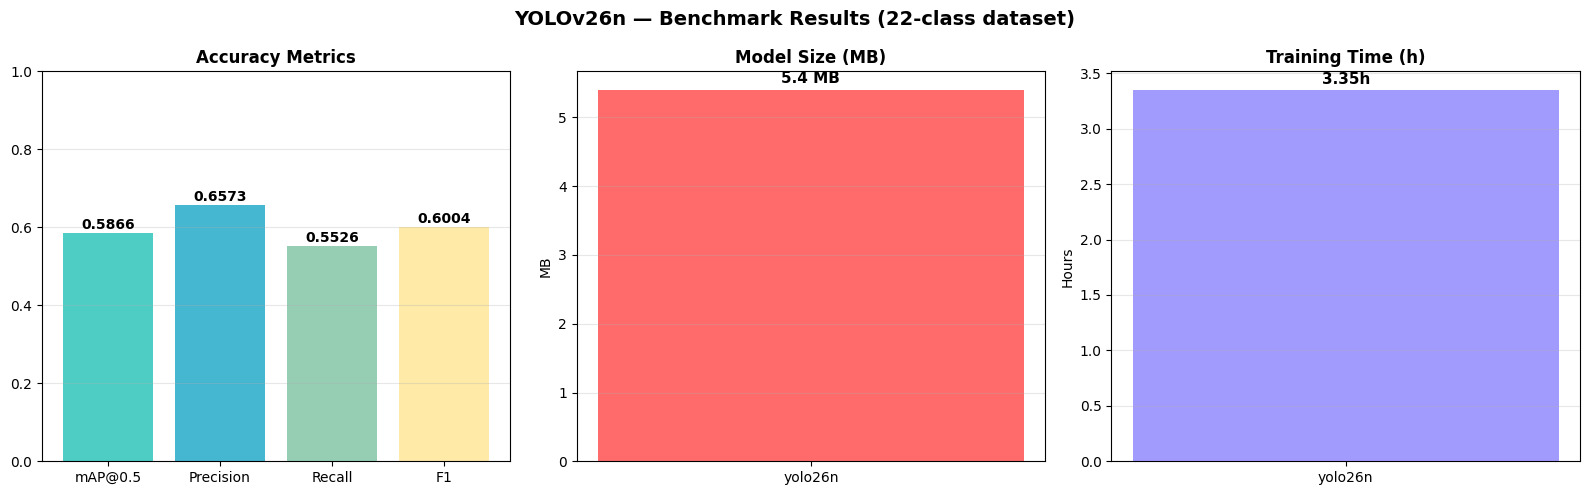


Best epoch: 55 / 95


In [1]:
# ═══ RESULTS TABLE: YOLOv26n (runs/detect) ═══
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

RUNS_BASE = Path("../runs/detect")

def load_best(folder):
    p = RUNS_BASE / folder / "results.csv"
    if not p.exists():
        return None, None
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    best = df.loc[df["metrics/mAP50(B)"].idxmax()]
    return best, len(df)

FALLBACK = {
    "yolo26n": dict(mAP50=0.58661, mAP50_95=0.41717, precision=0.65734, recall=0.55257,
                    time_s=12071.9, best_epoch=55, total_epochs=95, size_MB=5.4, params_M=2.5),
}

def extract(best, total, fb):
    if best is None:
        return fb
    p = float(best["metrics/precision(B)"])
    r = float(best["metrics/recall(B)"])
    return dict(mAP50=round(float(best["metrics/mAP50(B)"]),4),
                mAP50_95=round(float(best["metrics/mAP50-95(B)"]),4),
                precision=round(p,4), recall=round(r,4),
                time_s=float(best["time"]), best_epoch=int(best["epoch"]),
                total_epochs=total, size_MB=fb["size_MB"], params_M=fb["params_M"])

def f1(p, r): return round(2*p*r/(p+r), 4) if (p+r) > 0 else 0.0

data = extract(*load_best("yolo26n"), FALLBACK["yolo26n"])

rows = [{
    "Model": "yolo26n",
    "mAP@0.5":      data["mAP50"],
    "mAP@0.5:0.95": data["mAP50_95"],
    "Precision":    data["precision"],
    "Recall":       data["recall"],
    "F1":           f1(data["precision"], data["recall"]),
    "Size (MB)":    data["size_MB"],
    "Params (M)":   data["params_M"],
    "Best Epoch":   f"{data['best_epoch']}/{data['total_epochs']}",
    "Train Time (h)": round(data["time_s"]/3600, 2),
}]
df = pd.DataFrame(rows).set_index("Model")

print("=" * 60)
print("  VisionAid — YOLOv26n — runs/detect Results")
print("=" * 60)
print(df.to_string())

metric_cols = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1"]
styled = (
    df.style
    .set_caption("YOLOv26n — Best-Epoch Metrics (runs/detect)")
    .format({c: "{:.4f}" for c in metric_cols})
    .highlight_max(subset=metric_cols, color="#c6efce", axis=0)
    .set_properties(**{"text-align": "center", "font-size": "13px", "border": "1px solid #ddd"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","14px"),("font-weight","bold"),("padding","8px")]},
        {"selector": "th",      "props": [("background-color","#1a1a2e"),("color","white"),("font-size","12px"),("padding","8px")]},
        {"selector": "td",      "props": [("padding","7px 12px")]},
    ])
)
display(styled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("YOLOv26n — Benchmark Results (22-class dataset)", fontsize=14, fontweight="bold")
metrics_plot = ["mAP@0.5", "Precision", "Recall", "F1"]
vals = [data["mAP50"], data["precision"], data["recall"], f1(data["precision"], data["recall"])]
colors_bar = ["#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]
axes[0].bar(metrics_plot, vals, color=colors_bar)
axes[0].set_ylim(0, 1); axes[0].set_title("Accuracy Metrics", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(vals):
    axes[0].text(i, v+0.01, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

axes[1].bar(["yolo26n"], [data["size_MB"]], color="#FF6B6B", width=0.4)
axes[1].set_title("Model Size (MB)", fontweight="bold"); axes[1].set_ylabel("MB")
axes[1].grid(axis="y", alpha=0.3)
axes[1].text(0, data["size_MB"]+0.1, f"{data['size_MB']} MB", ha="center", fontsize=11, fontweight="bold")

axes[2].bar(["yolo26n"], [round(data["time_s"]/3600,2)], color="#A29BFE", width=0.4)
axes[2].set_title("Training Time (h)", fontweight="bold"); axes[2].set_ylabel("Hours")
axes[2].grid(axis="y", alpha=0.3)
axes[2].text(0, data["time_s"]/3600+0.05, f"{round(data['time_s']/3600,2)}h", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("benchmark_yolo26_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nBest epoch:", data["best_epoch"], "/", data["total_epochs"])


Per-Class mAP@0.5 — YOLOv26n
  spherical_roadblock    0.9468  ████████████████████████████
  waste_container        0.8985  ██████████████████████████
  bus                    0.8691  ██████████████████████████
  stop_sign              0.8691  ██████████████████████████
  bus_stop               0.8299  ████████████████████████
  train                  0.7927  ███████████████████████
  fire_hydrant           0.7715  ███████████████████████
  warning_column         0.7068  █████████████████████
  car                    0.6366  ███████████████████
  dog                    0.6131  ██████████████████
  bicycle                0.6092  ██████████████████
  motorcycle             0.6020  ██████████████████
  bench                  0.5963  █████████████████
  stairs                 0.5456  ████████████████
  truck                  0.5176  ███████████████
  crutch                 0.4907  ██████████████
  curb                   0.3837  ███████████
  traffic_light          0.3431  ██████████
  pers

class,mAP50
spherical_roadblock,0.9468
waste_container,0.8985
bus,0.8691
stop_sign,0.8691
bus_stop,0.8299
train,0.7927
fire_hydrant,0.7715
warning_column,0.7068
car,0.6366
dog,0.6131


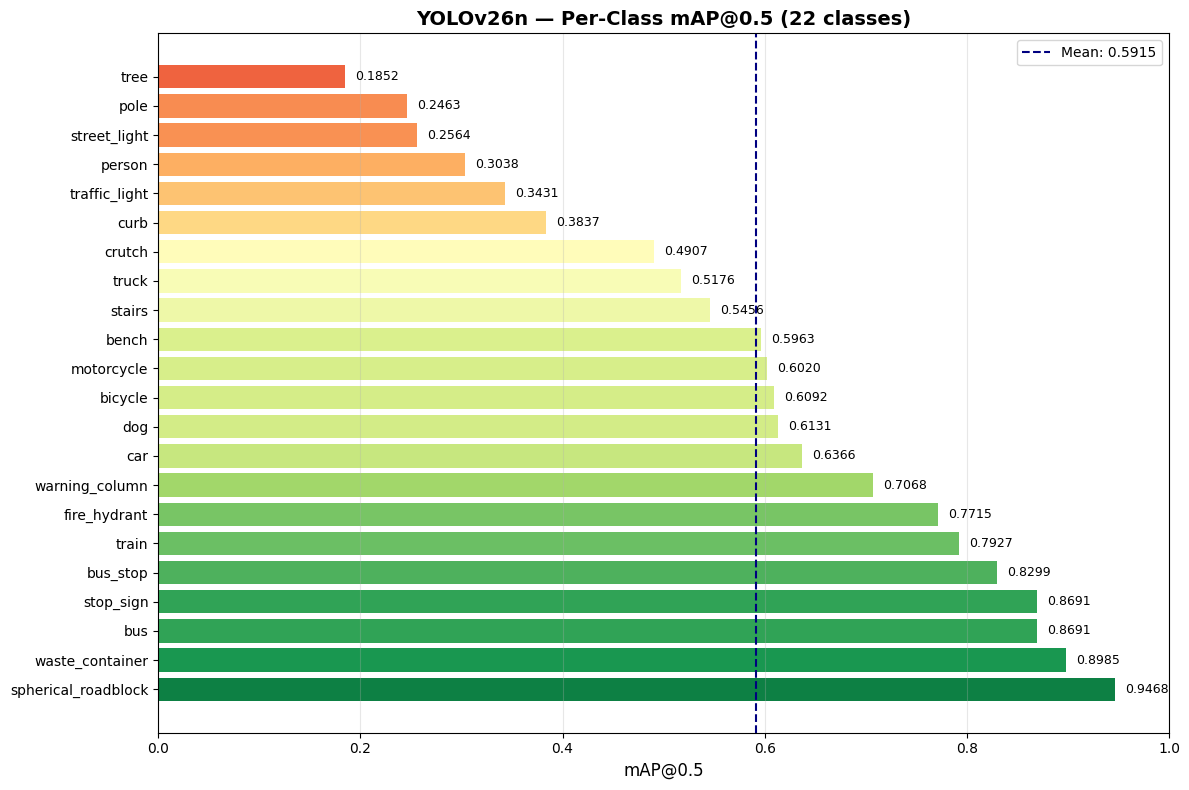


Mean mAP@0.5: 0.5915
Best class  : spherical_roadblock (0.9468)
Worst class : tree (0.1852)


In [1]:
# ═══ PER-CLASS mAP@0.5 — YOLOv26n ═══
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display

df = pd.read_csv("perclass_yolo26n.csv")
df = df.sort_values("mAP50", ascending=False).reset_index(drop=True)

print("Per-Class mAP@0.5 — YOLOv26n")
print("=" * 45)
for _, row in df.iterrows():
    bar = "█" * int(row["mAP50"] * 30)
    print(f"  {row['class']:22s} {row['mAP50']:.4f}  {bar}")

styled = (
    df.style
    .set_caption("Per-Class mAP@0.5 — YOLOv26n (22 classes, val split)")
    .format({"mAP50": "{:.4f}"})
    .background_gradient(subset=["mAP50"], cmap="RdYlGn", vmin=0, vmax=1)
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","14px"),("font-weight","bold"),("padding","8px")]},
        {"selector": "th",      "props": [("background-color","#1a1a2e"),("color","white"),("padding","8px")]},
        {"selector": "td",      "props": [("padding","6px 14px")]},
    ])
    .hide(axis="index")
)
display(styled)

fig, ax = plt.subplots(figsize=(12, 8))
colors = cm.RdYlGn(df["mAP50"].values)
bars = ax.barh(df["class"], df["mAP50"], color=colors)
ax.set_xlabel("mAP@0.5", fontsize=12)
ax.set_title("YOLOv26n — Per-Class mAP@0.5 (22 classes)", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1)
ax.axvline(x=df["mAP50"].mean(), color="navy", linestyle="--", linewidth=1.5, label=f"Mean: {df['mAP50'].mean():.4f}")
ax.legend()
ax.grid(axis="x", alpha=0.3)
for b, v in zip(bars, df["mAP50"]):
    ax.text(v + 0.01, b.get_y() + b.get_height()/2, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("perclass_yolo26n_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nMean mAP@0.5: {df['mAP50'].mean():.4f}")
print(f"Best class  : {df.iloc[0]['class']} ({df.iloc[0]['mAP50']:.4f})")
print(f"Worst class : {df.iloc[-1]['class']} ({df.iloc[-1]['mAP50']:.4f})")
